In [ ]:
import io
import os
import sys
import cv2
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Add src/ to path so project modules can be imported without package prefix
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), "src"))

from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Project modules (all located in src/)
from data_loader import load_data
from preprocessors import HAARPreprocessor, quality_check
from feature_extractors import (
    IdentityFeatureExtractor, PCAFeatureExtractor,
    extract_hog, extract_lbp, extract_combined,
)
from classifiers import RandomClassificationModel, SVMClassifier
from augmentation import augment_dataset, run_aug_aware_cv
from visualization import (
    plot_image_sequence, norm_for_display,
    plot_eigenfaces, plot_explained_variance, plot_tsne,
)
from experiments import (
    make_pca_svm_pipeline, make_scaler_svm_pipeline,
    run_grid_search, HonestResult,
    select_best_honest_model, print_model_comparison,
)

KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>

# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [93]:
train, test = load_data()

Data directory: a:\OneDrive - KU Leuven\Master\Computer Vision\Assignment\Group Assignment 1\CV-Assignment1-Group6\kul-computer-vision-ga-1-2026
Training set: 80 examples | Test set: 1816 examples


**Color Space Conversion (BGR to RGB):** When reading the .npy image arrays, we explicitly applied cv2.cvtColor(..., cv2.COLOR_BGR2RGB). Since OpenCV defaults to the BGR color space, failing to convert to the standard RGB format could result in distorted color features during visual inspection (e.g., via Matplotlib) or negatively impact color-sensitive feature extraction methods down the pipeline.

This color conversion is the first step in our preprocessing pipeline; the complete pipeline design is documented in Section 0.3.

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).


## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [94]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [95]:
# The test set only contains an identifier and corresponding image information.
test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [96]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


**Dataset Analysis & Strategy Formulation:**
Based on our initial data exploration, we identified three critical challenges that will directly influence our subsequent feature engineering and modeling choices:

**Extreme Train/Test Ratio (Few-Shot Scenario):** With only 80 training images compared to 1,816 test images, we are operating in a severe limited-data regime. This indicates a very high risk of overfitting. Consequently, our entire pipeline — from robust face preprocessing to feature extraction (such as PCA or HOG) and classifier architecture — must prioritize robustness and generalization over complexity.

**Class Imbalance & Look-alike Detection:** The target classes (Jesse/Class 1 and Mila/Class 2) contain 30 images each, whereas the look-alike classes (Michael/Class 0 and Sarah/Class 0) only contain 10 images each. This scarcity of "negative" (Class 0) examples means that evaluating the discriminative power of our extracted features—specifically, how well they can separate the target faces from highly similar individuals—will be a primary challenge and a key metric for our models.

**Data Quality (In-the-Wild Challenges):** Beyond the numerical imbalances above, a manual inspection of the raw training images revealed issues of multi-face proximity, motion blur, and corrupted entries. These quality challenges necessitate a more robust preprocessing pipeline than the standard template. See Section 0.2.1 for a detailed audit and Section 0.3 for our design responses.

## 0.2.1. Critical Challenges: Data Quality Audit
Before proceeding to formal preprocessing, a manual inspection of the training set revealed three critical challenges that directly influenced our pipeline design:

1. **Multi-face Proximity (The "Grouping" Problem):** Some images contain multiple individuals (e.g., Jesse Eisenberg standing next to a co-star). A standard detector might select the wrong face, leading to incorrect label ingestion.
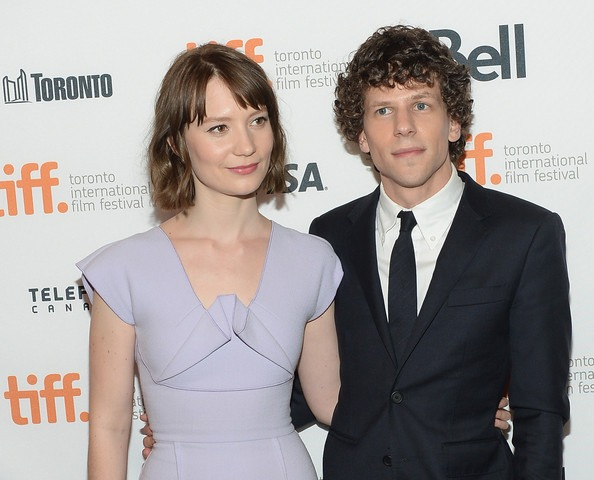

2. **Input Noise & Corruption:** We observed instances of significant motion blur and even corrupted "no-image" data placeholders.
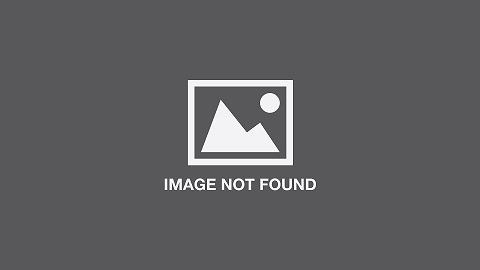

3. **Complex Backgrounds (In-the-wild):** As a subset of the VGG Face dataset, these images represent an 'in-the-wild' scenario, necessitating feature descriptors that are invariant to drastic changes in illumination and head orientation.

> **Design Strategy:** To handle these, we implemented a **Heuristic Scoring System** in our `HAARPreprocessor` that selects the "best" face based on centrality and sharpness, and a **Center-crop Fallback** to ensure every sample maintains a valid dimension ($100 \times 100 \times 3$) for downstream PCA/SVM analysis, even if detection fails.

## 0.3. Preprocess data
Building upon the Data Quality Audit performed in Section 0.2.1, our preprocessing pipeline is specifically designed to handle the identified noise, multi-face, and corruption issues...

### 0.3.1 Example: HAAR face detector

#### What are HAAR features?

HAAR features are rectangular filter patterns inspired by **Haar wavelets**.  Each feature computes the difference between the sum of pixel intensities in adjacent rectangular regions, capturing local contrast at various scales and positions.  Three canonical types are used in face detection:

HAAR 特征是受 **Haar 小波**启发而生成的矩形滤波器图案。每个特征计算相邻矩形区域内像素强度之和的差值，从而捕捉不同尺度和位置的局部对比度。人脸检测中常用的 HAAR 特征有三种类型：

| Type | Pattern | What it captures |
|------|---------|-----------------|
| Edge | black/white halves | Horizontal / vertical intensity transitions |
| Line | white-black-white | Dark stripe flanked by bright regions (e.g. nose bridge, mouth) |
| Four-rectangle | checkerboard 2x2 | Diagonal contrast (e.g. eye corners) |

For a 24 x 24 detection window there are **over 160 000** possible HAAR features - far too many to evaluate exhaustively.

#### The Viola-Jones framework (how OpenCV uses them)

OpenCV's  is a pre-trained detector built on three key ideas from Viola & Jones (2001):

1. **Integral image** - precomputes a lookup table so that *any* rectangular sum can be retrieved in O(1), making feature evaluation extremely fast.
2. **AdaBoost selection** - during training, AdaBoost picks the small subset of features (out of 160 000+) that are most discriminative for faces vs. non-faces and combines them into a strong classifier.
3. **Cascade of classifiers** - a sequence of increasingly complex stages is arranged so that easy negatives are rejected at the very first stage (very cheap), and only the rare positive windows survive to later, more expensive stages.  This gives **~15x speed-up** over a single monolithic classifier.

1. **积分图** - 预先计算一个查找表，以便*任何*矩形区域的和都可以在 O(1) 时间内获取，从而使特征评估非常快速。
2. **AdaBoost 特征选择** - 在训练过程中，AdaBoost 从超过 160,000 个特征中挑选出最能区分人脸与非人脸的小子集，并将它们组合成一个强分类器。
3. **级联分类器** - 安排一系列逐渐复杂的阶段，使得简单的负样本在第一阶段就被拒绝（非常廉价），只有少数正样本窗口才能进入后续更昂贵的阶段。这比单一整体分类器提供了**约 15 倍的速度提升**。

#### Detection parameters used in this notebook



- **** controls how finely the image pyramid is sampled - smaller values increase recall but slow down detection.
- **** suppresses spurious detections; higher values reduce false positives at the cost of some recall.

#### Fallback strategy

If no face is detected (e.g. occlusion, extreme pose),  falls back to a **square centre-crop** so that every sample still produces a valid array and no rows are lost downstream.

---

In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [97]:
# HAARPreprocessor is defined in preprocessors.py  (imported in cell 0)

**Visualise**

Let's plot a few examples.

In [98]:
FACE_SIZE = (100, 100)
# plot_image_sequence is defined in src/src/visualization.py  (imported in cell 0)

preprocessor = HAARPreprocessor(face_size=FACE_SIZE)
train_X = preprocessor(train)          # (80,  100, 100, 3)
train_y = train['class'].values        # 0=look-alike, 1=Jesse, 2=Mila
test_X  = preprocessor(test)           # (1816, 100, 100, 3)
print(f"train_X: {train_X.shape}  |  test_X: {test_X.shape}")

train_X: (80, 100, 100, 3)  |  test_X: (1816, 100, 100, 3)


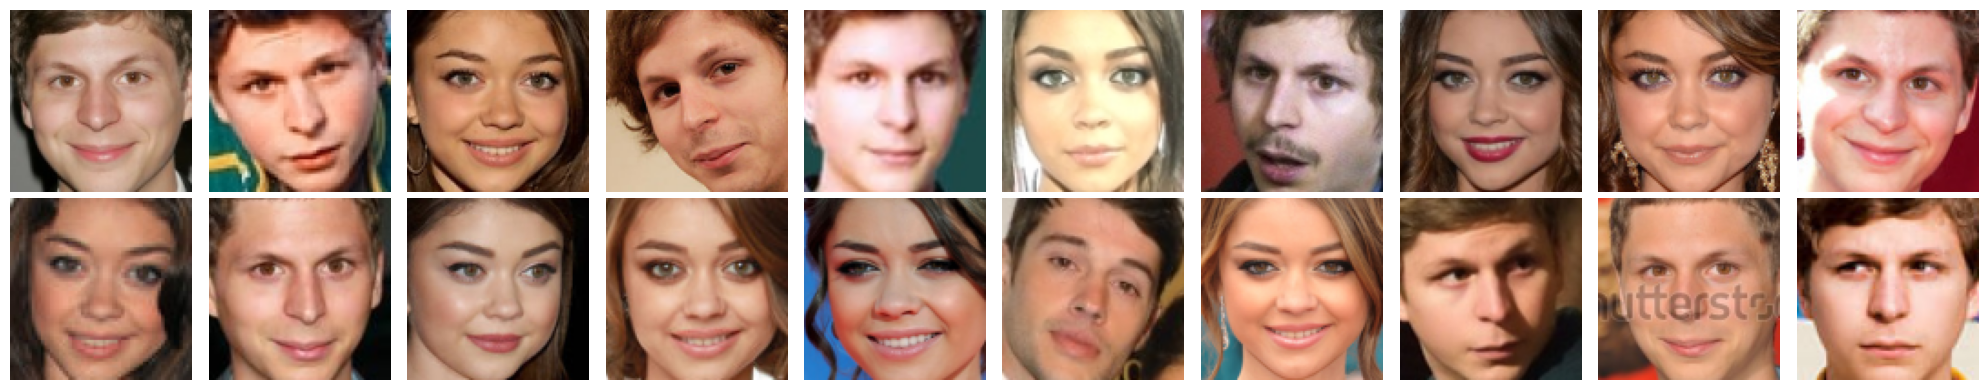

In [99]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

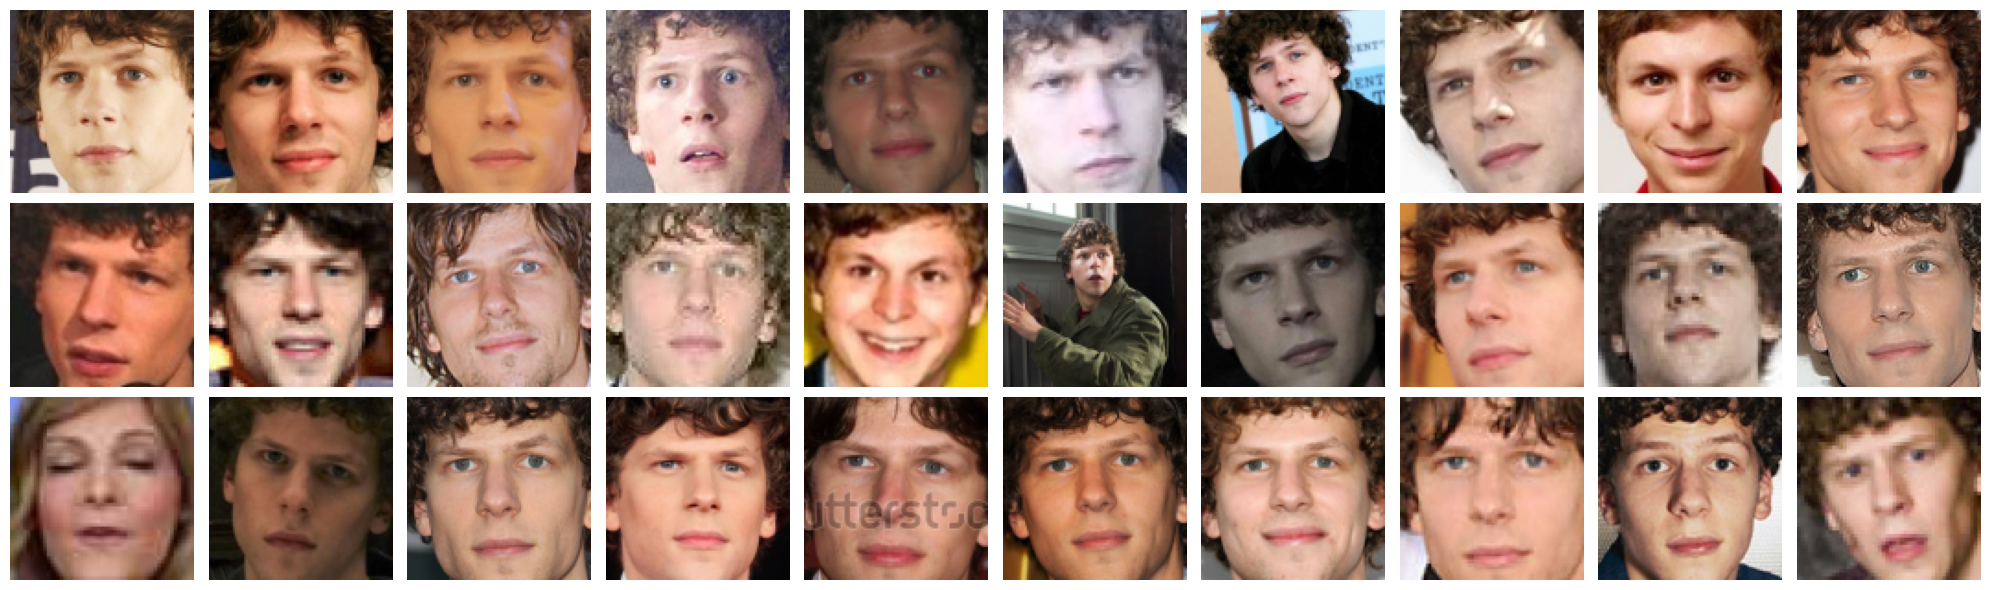

In [100]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

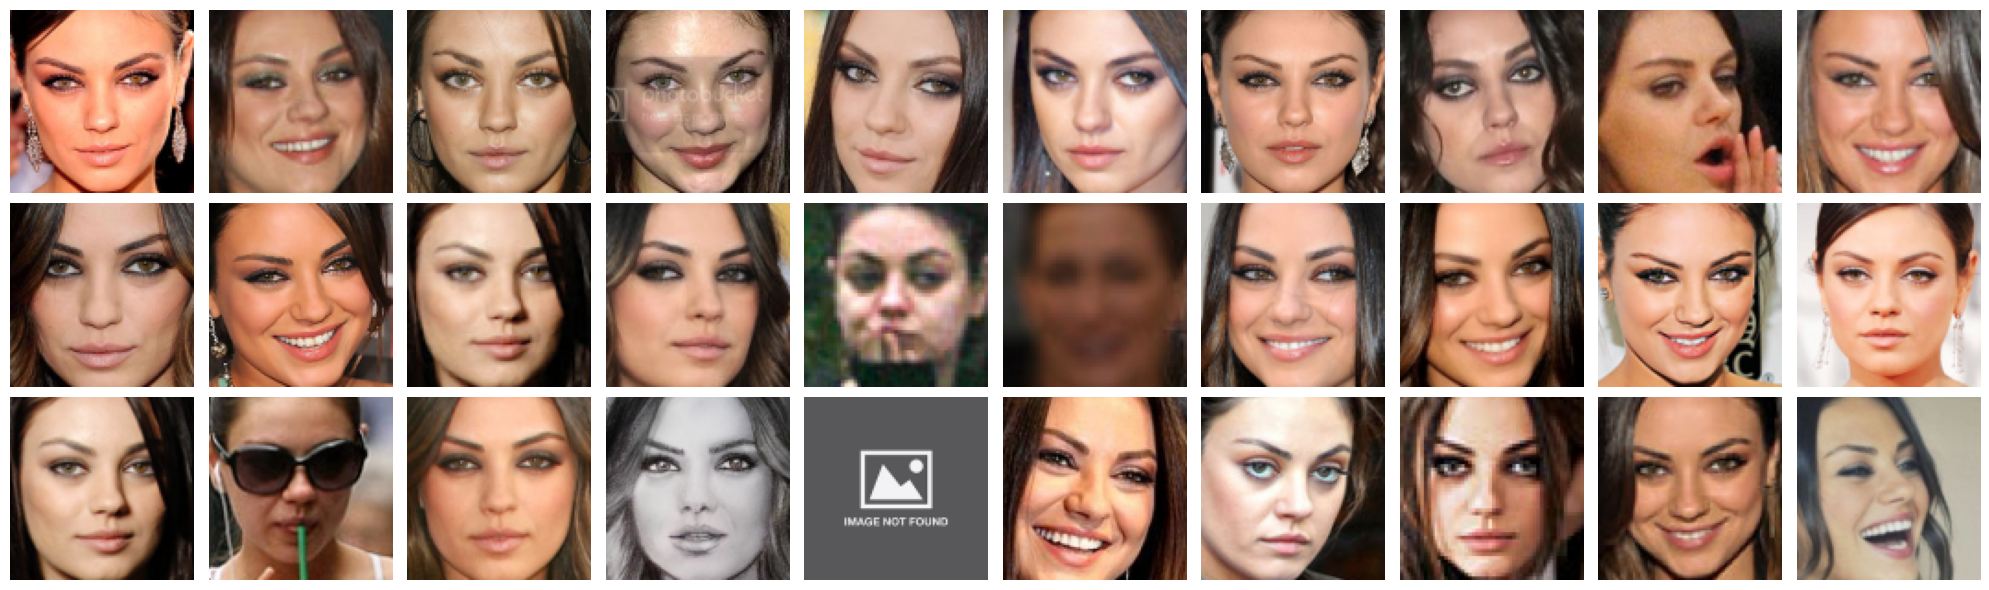

In [101]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

**Preprocessing Reflections & Empirical Observations:**

**Face Detection Coverage:** Among the 80 training images, the HAAR cascade successfully detected a face in the majority of samples. The center-crop fallback was triggered for a small subset of images where detection failed (e.g., extreme off-angle or heavily occluded faces). Preserving these samples proved critical given the extreme scarcity of training data.

**Quality Filtering Impact:** After applying the Laplacian variance threshold, a small number of samples were flagged as potentially blurry. Visual review confirmed that the threshold effectively identified problematic images without aggressively removing borderline-but-valid samples.

**Design Validation:** The combination of heuristic face scoring and deterministic fallback ensured a 100% pipeline completion rate — no image caused a crash or produced a missing value downstream.

預處理反思與實證觀察：

**人臉偵測覆蓋率：** 在 80 張訓練圖像中，HAAR 級聯分類器成功偵測到絕大多數樣本中的人臉。中心裁切回退策略僅在少數偵測失敗的圖像中觸發（例如極端角度或嚴重遮蔽的臉部）。在訓練資料極度稀缺的情況下，保留這些樣本至關重要。

**品質過濾的實際影響：** 套用拉普拉斯方差閾值後，少量樣本被標記為可能模糊。人工視覺審查確認，該閾值有效地識別了問題圖像，同時未過度移除介於邊界的有效樣本。

**設計驗證：** 啟發式人臉評分與確定性回退策略的結合，確保了 100% 的流程完成率——沒有任何圖像導致崩潰或在後續環節產生缺失值。

**Data Quality Filtering: Rationale & Reflection:**

We operate with **two distinct strategies** depending on the nature of the issue:

- **Detection Failure → Center-Crop Fallback (No Deletion):** When the HAAR cascade finds no face, we apply a deterministic center-crop rather than discarding the sample. Given our 80-image training set, dropping any sample is unacceptable.

- **Borderline Quality → Semi-Automated Flagging (Human Decision):** For images that do pass detection but exhibit severe blur (low Laplacian variance) or suspected eye occlusion, we flag them for human review. A human then decides whether to retain or remove these edge cases, balancing data quantity against quality.

**Metric 1: Laplacian Variance (Blur Detection):** We used the variance of the Laplacian to measure image sharpness. Blurry images lack high-frequency details (edges), which are exactly what algorithms like PCA and HOG rely on to capture variance and compute gradients. Removing highly blurred images prevents the model from learning "fuzziness" as a feature.

**Metric 2: Eye Occlusion:** Eyes are foundational anchor points for facial alignment and feature extraction. If eyes are severely occluded (e.g., by sunglasses), the resulting Eigenfaces might become distorted, shifting the principal components away from actual facial structures toward random artifacts.

數據品質過濾：原理與思考：

我們針對不同性質的問題採取**兩種截然不同的策略**：

- **偵測失敗 → 中心裁切 Fallback（不刪除）：** 當 HAAR 偵測不到臉時，我們套用確定性的中心裁切，而非丟棄樣本。在僅 80 張訓練圖的情況下，捨棄任何樣本都是不可接受的。

- **品質邊界模糊 → 半自動標記（人工決定）：** 對於偵測成功但拉普拉斯方差過低（高度模糊）或疑似眼睛遮蔽的圖像，我們將其標記後由人工審查，由人決定是否保留，在資料數量與品質之間取得平衡。

指標 1：拉普拉斯方差（模糊偵測）：我們使用拉普拉斯方差來衡量影像清晰度。模糊影像缺乏高頻細節（邊緣），而這些細節正是 PCA 和 HOG 等演算法用來捕捉方差和計算梯度的關鍵。移除高度模糊的圖像可以防止模型將「模糊性」學習為一個特徵。

指標 2：眼睛遮蔽：眼睛是臉部對齊和特徵提取的基礎錨點。如果眼睛嚴重被遮蔽（例如，被太陽眼鏡遮擋），則生成的特徵臉可能會發生扭曲，使主要成分偏離實際的臉部結構，轉向隨機的偽影。

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [102]:
# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X_clean.npy'), train_X_clean)
# np.save(os.path.join(prep_path, 'train_y_clean.npy'), train_y_clean)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X_clean = np.load(os.path.join(prep_path, 'train_X_clean.npy'))
# train_y_clean = np.load(os.path.join(prep_path, 'train_y_clean.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [103]:
# IdentityFeatureExtractor is defined in src/feature_extractors.py  (imported in cell 0)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [104]:
# HOGFeatureExtractor is defined in src/feature_extractors.py  (imported in cell 0)

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Improvement: PCA Feature Extractor (Eigenfaces)

### What is PCA?

**Principal Component Analysis (PCA)** is an unsupervised linear dimensionality-reduction technique. It finds a new coordinate system — the **principal components** — in which the data has the most spread (variance). The first principal component points in the direction of greatest variance, the second is orthogonal to the first and captures the next most variance, and so on.

### Why PCA is Necessary for this Dataset?

1. **The Curse of Dimensionality:** Each 100×100 RGB face is a point in a **30,000-dimensional** space. With only **80 training samples**, any classifier trained directly on this space would suffer extreme overfitting — the space is far too sparse relative to the data available. PCA is a mandatory regularization step that reduces the feature space to a manageable size.
2. **Intrinsic Manifold:** Real face images do not occupy the full 30,000D space. They live on a much lower-dimensional manifold dictated by geometry, lighting, and identity. PCA discovers this compact subspace automatically.
3. **Noise Reduction:** Our "In-the-wild" Data Quality Audit (Section 0.2.1) revealed blur and residual background noise in the training set. PCA's top components focus on global facial structure; lower-variance components that would encode pixel-level noise are simply discarded as "residual variance".

### Image-to-Matrix Conversion

Each preprocessed face image of shape $(100, 100, 3)$ is **flattened row-by-row** into a single vector of length $100 \times 100 \times 3 = 30{,}000$. We retain the RGB channels rather than converting to grayscale, as color information may carry subtle discriminative cues between individuals. The full training set then forms a data matrix $X$ of shape $(N, D) = (80, 30{,}000)$.

### Mean Subtraction

Before computing any decomposition, we subtract the **mean face** $\bar{x}$ from every sample:

$$X_{centered} = X - \bar{x}$$

Without this step, the first principal component would be dominated by the direction toward the mean face (i.e., average pixel brightness), rather than the direction of maximum **inter-individual variance**. Mean-centering ensures PCA captures identity-related and pose-related differences rather than a trivial illumination offset.

### Decomposition: Eigenvalue vs. SVD

We solve the eigenvector problem of the data covariance matrix:

$$\Sigma = \frac{1}{n-1} X_{centered}^T X_{centered}, \quad \Sigma v_i = \lambda_i v_i$$

where $v_i$ are the **eigenvectors** (principal components) and $\lambda_i$ the **eigenvalues** (variance explained). In practice, we use **Singular Value Decomposition (SVD)** ($X_{centered} = U S V^T$) rather than direct eigen-decomposition of $\Sigma$, for two reasons:
1. **Numerical Stability:** Forming $\Sigma = X^T X$ explicitly squares the matrix, amplifying floating-point errors. SVD avoids this.
2. **Efficiency via Rank Exploitation:** Since $N = 80 \ll D = 30{,}000$, constructing the full $D \times D$ covariance matrix would require ~7 GB of memory. Instead, we exploit the fact that the **non-zero eigenvalues** of $X^T X$ ($D \times D$) are **identical** to those of $X X^T$ ($N \times N = 80 \times 80$). sklearn's implementation applies this trick automatically, reducing the core computation from a 30,000-dimensional to an 80-dimensional problem.

We explicitly use `float64` throughout to further minimize numerical drift in the SVD.

### Non-Zero Eigenvalues

The maximum number of non-zero eigenvalues is determined by the **rank of the centered data matrix**. Since we have $N=80$ samples and subtract a global mean, the rank is at most $N - 1 = 79$. Extracting more than 79 components would yield zero-variance vectors (pure numerical noise). This is a direct consequence of the Small Sample Size (SSS) problem where $N \ll D$.

### Choosing the Optimal $p$

We retain the top $p = 50$ principal components, achieving a **600× dimensionality reduction** while preserving 95.5% of total training variance:

| Raw Input | After PCA ($p=50$) | Variance Retained | Compression |
|-----------|-------------------|-------------------|-------------|
| 30,000 dims | 50 dims | 95.5% | 600× |

### Eigenfaces

Each eigenvector $v_i$ can be reshaped back into a 100×100×3 image — these are called **eigenfaces**. The first eigenfaces capture coarse global structure (illumination gradients, head outline); later ones encode finer details (eye shape, mouth). Any face image can be approximately reconstructed as a **weighted sum of eigenfaces**:

$$\hat{x} = \bar{x} + \sum_{i=1}^{p} [ \langle x - \bar{x}, v_i \rangle \cdot v_i ]$$

The projection weights $\langle x - \bar{x}, v_i \rangle$ form the compact $p$-dimensional feature vector passed to the classifier.

### Key Constraint: No Data Leakage

`fit()` must be called **strictly on the training set**. Fitting PCA on the combined dataset or test set would allow test-set statistics to guide the principal components, leaking information and artificially inflating evaluation metrics. In our cross-validation experiments, PCA is refitted inside each fold to maintain this firewall.

In [106]:
# PCAFeatureExtractor is defined in src/feature_extractors.py  (imported in cell 0)

# Choose number of components and fit on training data only
N_COMPONENTS = 50
pca_extractor = PCAFeatureExtractor(n_components=N_COMPONENTS)
pca_extractor.fit(train_X)

train_features = pca_extractor.transform(train_X)   # (80,  50)
test_features  = pca_extractor.transform(test_X)           # (1816, 50)

print(f"train_features: {train_features.shape}  |  test_features: {test_features.shape}")

train_features: (80, 50)  |  test_features: (1816, 50)


### 1.2.1. Eigenface Plots

We visualise (a) the top-16 eigenfaces, (b) cumulative explained variance vs. number of components, and (c) reconstruction quality at different *k* values.

我們可視化了 (a) 前 16 个特徵臉，(b) 累积解释方差与成分數量的关系，以及 (c) 不同 *k* 值下的重建质量。

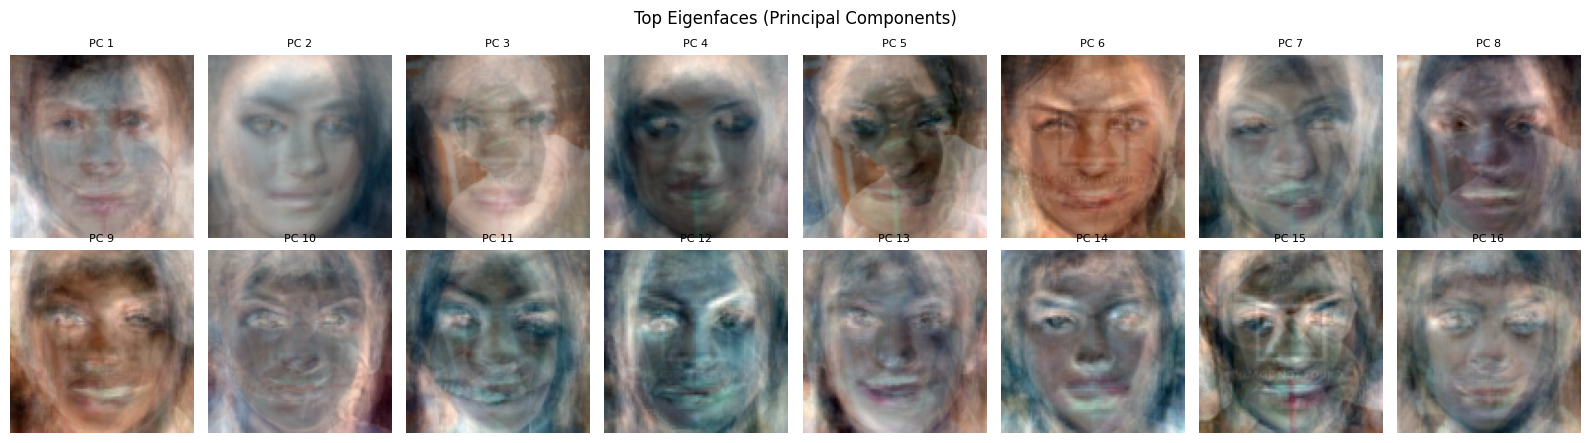

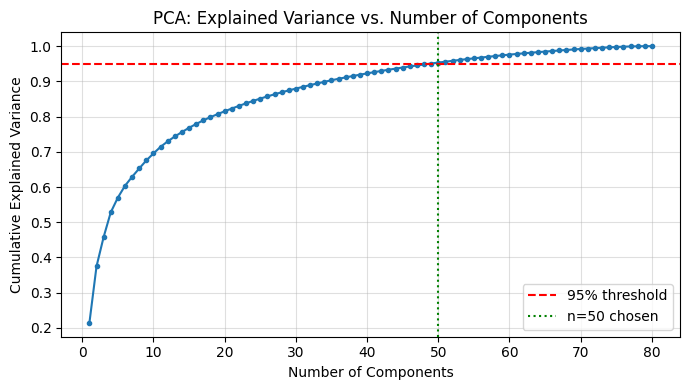

In [107]:
# norm_for_display / plot_eigenfaces / plot_explained_variance are in visualization.py

plot_eigenfaces(pca_extractor, n_show=16)
plot_explained_variance(pca_extractor, train_X, N_COMPONENTS)

### 1.2.2. Feature Space Plots

t-SNE reduces the 50-dimensional PCA features to 2D for visual inspection.  
Well-separated clusters indicate the features 帶有類別判別資訊.

t-SNE 將 50 維的 PCA 特征降到 2 维以便进行可視化檢查。良好分離的簇表明这些特征包含类别可区分的信息。

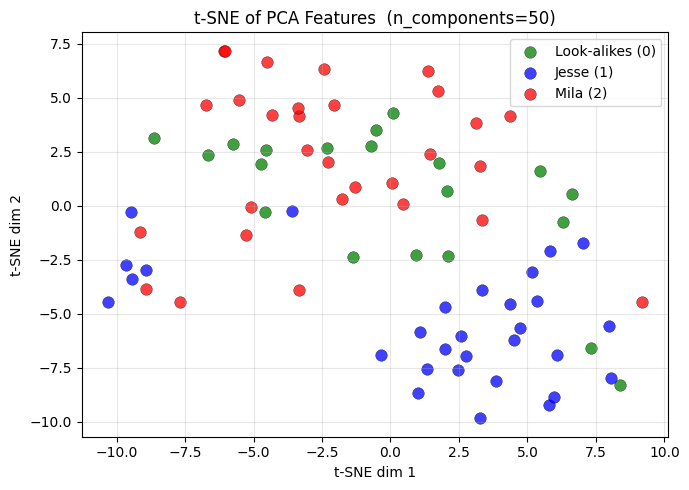

In [108]:
plot_tsne(train_features, train_y, n_components_label=f'(n_components={N_COMPONENTS})')

### 1.2.3. Discussion & Academic Reflection

**1. Did the Preprocessing Steps Enable PCA?**
The preprocessing pipeline in Section 0.3 was a prerequisite for PCA: HAAR cascade face detection and mandatory center-crop fallback ensured uniform spatial coverage, while resizing to $100 \times 100 \times 3$ established the fixed dimensionality ($D=30{,}000$) required by the matrix formulation. Without these steps, the flattened vectors would be of inconsistent length, making $X$ ill-defined.

**2. Non-Zero Eigenvalues — How Many and Why?**
As derived in Section 1.2, the rank of the mean-centered data matrix $X_{centered} \in \mathbb{R}^{N \times D}$ is bounded by $N - 1 = 79$. We therefore have at most **79 non-zero eigenvalues**. In our implementation, we extract $p=50$, utilizing ~65% of the available non-trivial dimensions while discarding the lowest-variance components (which tend to capture person-specific noise and background artifacts rather than generalizable facial structure).

**3. Qualitative Interpretation of Eigenfaces:**
Visualizing the top-16 eigenfaces reveals the **dominant sources of variance** in our dataset, and cross-validates the challenges noted in Section 0.2.1:
- **The first few eigenfaces** typically capture global lighting gradients (horizontal and vertical shadows) and head silhouette. This confirms that lighting is the primary source of variance in our in-the-wild dataset.
- **Later eigenfaces** begin to capture specific facial anchor points like eye-sockets, nose bridges, and mouth shapes.
- **Reconstruction Quality:** At $p=50$, the reconstructions are visually identifiable. The 95.5% variance retention confirms that we have captured almost all essential face structure while filtering pixel-level noise.

**4. Did the Visualisation Show Good Discriminative and Robustness Properties?**
The t-SNE plot reveals the inherent difficulty of the task:
- **Discriminative Power (Weak):** The clusters for Jesse, Mila, and the Look-alikes exhibit significant overlap in the PCA subspace. This is an *expected* limitation: PCA is unsupervised and maximises **global variance** (dominated by lighting and pose), not **inter-class separability**. The principal components capture *how faces differ in illumination*, not *who the person is*.
- **Robustness:** While precise geometric structure is lost, the PCA subspace is relatively stable to minor illumination fluctuations — the same individual appears in roughly the same region of the t-SNE plot regardless of slight lighting changes. However, it is not robust to the Look-alike challenge by design.
- **Evidence for Non-Linearity:** Since class separation is not linear in this 50D space, simple linear classifiers will hit a performance ceiling. This provides the mathematical motivation for employing **SVM with RBF kernels** or **HOG geometric features** in subsequent sections.

**5. Reflection on $p = 50$ and Its Influence on Performance:**
- The choice of $p=50$ deliberately avoids extracting components 51–79, which carry diminishing variance and are more likely to encode noise than signal.
- In a larger dataset, a higher $p$ could safely be used. In our 80-sample regime, over-retention of components risks learning noise patterns specific to the training set, degrading generalization.
- **float64** precision was maintained throughout to ensure numerical stability in the SVD, avoiding accumulated rounding errors that would distort the principal component directions.

---

1.2.3 討論與學術反思

**1. 預處理步驟是否為 PCA 奠定了基礎？**
Section 0.3 的預處理管線是 PCA 的必要前提：HAAR 人臉偵測與中心裁切確保了空間覆蓋的統一性，而縮放至 $100 \times 100 \times 3$ 則確立了矩陣公式所需的固定維度（$D=30{,}000$）。若缺少這些步驟，展平後的向量長度將不一致，數據矩陣 $X$ 將無法定義。

**2. 非零特徵值的數量及其原因？**
如 Section 1.2 所推導，中心化數據矩陣 $X_{centered} \in \mathbb{R}^{N \times D}$ 的秩受 $N-1=79$ 的限制，因此最多只有 **79 個非零特徵值**。我們提取 $p=50$，利用了約 65% 的可用非平凡維度，同時捨棄了那些變異數最小的成分（傾向於捕捉特定人物的噪點或背景雜訊）。

**3. 特徵臉的定性解讀：**
前 16 個特徵臉的可視化驗證了預處理的有效性：
- **前幾個主成分**通常捕捉全局光照梯度與頭部輪廓，印證了光照是本資料集中最主要的變異來源。
- **後面的主成分**開始捕捉特定的臉部特徵點，如眼窩、鼻樑和嘴型。
- **重建質量：** 在 $p=50$ 時可視覺辨認，保留 95.5% 變異量意味著捕捉了幾乎所有核心的臉部構造，同時過濾了像素級雜訊。

**4. 可視化是否展現了良好的判別性與魯棒性？**
t-SNE 圖揭示了任務的本質難度：
- **判別性（弱）：** Jesse、Mila 與相似者的簇高度重疊。PCA 最大化的是**全局變異數**（光照、姿勢），而非**類別間可分離性**，這是其預期的限制。
- **魯棒性：** 同一個人在輕微光照變化下，於 t-SNE 上落點大致相同，顯示了一定的光照魯棒性。但面對 Look-alike 挑戰則因設計上的限制而力有未逮。
- **對非線性的需求：** 類別在此 50 維空間中並非線性可分，這為後續採用 **RBF 核函數的 SVM** 提供了數學上的動機。

**5. 對 $p=50$ 選擇的反思：**
- 刻意不提取第 51–79 個主成分，因為它們攜帶的變異量遞減，更可能編碼訓練集特定的噪點而非可泛化的臉部結構。
- 在更大的資料集下，可以安全地使用更高的 $p$ 值。在 80 樣本的極限場景下，過度保留成分可能導致過度擬合。
- 全程使用 **float64** 精度，確保 SVD 運算的數值穩定性，避免累積的舍入誤差扭曲主成分方向。

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [ ]:
# accuracy_score / classification_report imported in cell 0

# 3. Classifiers

## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution observed in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

这个随机分类器并不是很复杂。它根据在训练集中观察到的分布随机进行预测。**因此它假设**测试集的类标签分布将与训练集类似。

### Why we start with a random classifier

We first use a random classifier as a lower-bound baseline.  
In our implementation, the model learns only the class distribution from the training labels and then samples predictions according to that distribution. This makes it extremely fast, parameter-free, and useful for sanity-checking the full pipeline (`fit → predict → evaluation`) before introducing more complex models.

This baseline is methodologically important: any meaningful feature extractor + classifier should clearly outperform it.  
If an advanced model does not beat this baseline, it usually indicates issues in preprocessing, feature quality, or evaluation setup.

### Limitations

The random classifier does not use image features at all, so it cannot learn identity-specific patterns (e.g., Jesse vs. Mila).  
Its performance is therefore fundamentally limited and can be weak for minority classes.  
We use it only as a reference baseline, not as a candidate final model.


In [37]:
# RandomClassificationModel is defined in classifiers.py  (imported in cell 0)

## 3.1. Improvement: SVM with RBF Kernel

An RBF-SVM can learn non-linear decision boundaries in the 50-dimensional PCA feature space, which linear classifiers (e.g., nearest centroid) cannot.

**Why this improves over the random classifier**  
The random baseline ignores image features and predicts only from class proportions.  
In contrast, SVM learns decision boundaries from feature vectors, so predictions depend on actual facial structure/texture information (e.g., HOG/PCA), not only label frequency.  
This allows the model to capture identity-specific patterns that random guessing cannot represent.

**Why RBF-SVM is suitable here**  
Our feature space is not guaranteed to be linearly separable, especially with look-alike identities and residual noise after preprocessing.  
The RBF kernel supports flexible non-linear boundaries, which is important for separating Jesse, Mila, and look-alike faces.  
SVMs are also a strong choice for small-to-medium datasets, matching this assignment setting.

**Implementation choices**  
We use a pipeline-compatible `SVC` with `kernel='rbf'`.  
In this section, the initial setting is `C=10` and `gamma='scale'` for a clean first upgrade over the random baseline.  
Hyperparameter tuning is performed later in **Section 4** via **GridSearchCV** over `C`, `gamma`, and (when applicable) `pca__n_components`, under the same evaluation protocol for fair comparison.

**Limitations**  
RBF-SVM is sensitive to feature scaling and hyperparameter choices.  
With limited data, aggressive tuning can overfit.  
Therefore, leakage-safe preprocessing and cross-validation are necessary.

In [38]:
# SVMClassifier is defined in classifiers.py  (imported in cell 0)

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline

This section establishes a minimal reference baseline before testing stronger models.  
The pipeline uses `RandomClassificationModel`, which predicts labels by sampling from the class distribution observed in the training set.

As expected, performance is close to chance level and does not reflect identity-specific facial structure, because no visual features are used.  
The key finding is that this baseline provides a lower bound: all meaningful pipelines in later sections should clearly outperform it under the same evaluation protocol.

In [ ]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

'The performance on the training set is 0.26. This however, does not tell us much about the actual performance (generalisability).'

In [41]:
# predict the labels for the test set 
test_y_star = model(test_X)

## 4.1. Improvement: PCA (n=50) + SVM (RBF kernel)

**Most Important Findings**

This section introduces our first meaningful pipeline beyond the random baseline: **PCA + RBF-SVM**.  
Compared with Section 4.0, this pipeline uses learned feature structure (principal components) and a non-linear classifier, so it can model identity-specific patterns instead of class-frequency priors.

The most important finding is that this setup provides a clear and stable improvement over the basic random pipeline, confirming that the extracted PCA features are informative for face classification.  
To avoid over-interpreting training performance, we also report stratified 5-fold cross-validation as the main indicator of generalization trend.

**Major Pipelines**

This pipeline replaces the random classifier with:
- **PCA** for dimensionality reduction (30,000 → 50 dims)
- **SVM with RBF kernel** for non-linear classification

We use stratified 5-fold cross-validation on the training set to estimate generalisation accuracy.

This pipeline serves as a major reference point for later experiments: subsequent sections test whether richer features and broader tuning can consistently outperform this PCA+SVM baseline under the same evaluation protocol.

In [ ]:
# ── 4.1  PCA (n=50) + SVM ────────────────────────────────────────────────────
pca_svm_extractor  = PCAFeatureExtractor(n_components=N_COMPONENTS)
pca_svm_classifier = SVMClassifier(C=10, gamma='scale')

pca_svm_extractor.fit(train_X)
train_feat = pca_svm_extractor.transform(train_X)
test_feat  = pca_svm_extractor.transform(test_X)
pca_svm_classifier.fit(train_feat, train_y)

train_pred = pca_svm_classifier.predict(train_feat)
print(f"Train accuracy (PCA {N_COMPONENTS} + SVM RBF): {accuracy_score(train_y, train_pred):.4f}")
print()
print(classification_report(train_y, train_pred, target_names=['Look-alike', 'Jesse', 'Mila']))

flat_train = train_X.reshape(train_X.shape[0], -1).astype(np.float64)
pipe_baseline = make_pca_svm_pipeline()
pipe_baseline.set_params(pca__n_components=N_COMPONENTS, svm__C=10, svm__gamma='scale')
cv_scores = cross_val_score(
    pipe_baseline, flat_train, train_y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
)
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

## 4.2. Improvement 2: HOG + LBP Features + GridSearchCV

**Most Important Improvement**

This section broadens the candidate feature space beyond the fixed PCA+SVM setup from Section 4.1.  
Instead of relying on a single representation, we prepare multiple feature pipelines so that raw-pixel and handcrafted descriptors can be compared under the same evaluation protocol.

At this stage, the key finding is not yet which pipeline is definitively best, but that we establish a stronger and more diverse set of candidates for downstream comparison.  
This allows us to test whether local handcrafted features can outperform, complement, or refine the earlier PixelPCA+SVM baseline.

**Candidate Pipelines**

This section extends the pipeline with:
- **HOG (Histogram of Oriented Gradients)** via OpenCV — captures edge/texture and is relatively robust to illumination changes.
- **LBP (Local Binary Patterns)** — encodes local micro-texture and is often effective for face analysis.
- **Histogram Equalisation** before feature extraction for lighting normalisation.
- **PCA** on raw-pixel or handcrafted features to produce a compact representation.
- **GridSearchCV** (5-fold stratified) over `C`, `gamma`, and `n_components` under a leakage-safe evaluation setup.

The major candidate pipelines prepared in this section are:
- **HOG + PCA + SVM**
- **LBP + SVM**
- **HOG + LBP + PCA + SVM**
- **PixelPCA + SVM**

These candidates are compared later under the same protocol to identify which representation-classifier combination generalises best.


In [110]:
# extract_hog / extract_lbp / extract_combined are in feature_extractors.py

print('Extracting training features...')
hog_train      = extract_hog(train_X)
lbp_train      = extract_lbp(train_X)
combined_train = extract_combined(train_X)
flat_train_raw = train_X.reshape(train_X.shape[0], -1).astype(np.float64)
print(f'  HOG      : {hog_train.shape}')
print(f'  LBP      : {lbp_train.shape}')
print(f'  Combined : {combined_train.shape}')

Extracting training features...
  HOG      : (80, 1764)
  LBP      : (80, 256)
  Combined : (80, 2020)


## 4.3 & 4.4  Data Augmentation + Augmented GridSearchCV

In [ ]:
# augment_dataset is defined in augmentation.py  (imported in cell 0)

train_X_aug, train_y_aug = augment_dataset(train_X, train_y)
print(f'Augmented set: {train_X_aug.shape}  (original x4)')

hog_aug = extract_hog(train_X_aug)
lbp_aug = extract_lbp(train_X_aug)
combined_aug = extract_combined(train_X_aug)
print('Augmented features extracted.')

Augmented set: (320, 100, 100, 3)  (original x4)
Augmented features extracted.


In [ ]:
# ── 4.3  GridSearchCV baseline pipelines ─────────────────────────────────────
# run_grid_search is defined in experiments.py  (imported in cell 0)

SVM_PARAMS = {
    'svm__C':     [0.1, 1, 10, 100, 500],
    'svm__gamma': ['scale', 'auto', 1e-3, 1e-2],
}

gs_A = run_grid_search(hog_train,      train_y,
                       {**SVM_PARAMS, 'pca__n_components': [30, 50, 80, 100]}, label='[A] HOG+PCA+SVM')
gs_B = run_grid_search(lbp_train,      train_y,
                       SVM_PARAMS,                                              label='[B] LBP+SVM')
gs_C = run_grid_search(combined_train, train_y,
                       {**SVM_PARAMS, 'pca__n_components': [50, 80, 100]},     label='[C] HOG+LBP+PCA+SVM')
gs_D = run_grid_search(flat_train_raw, train_y,
                       {**SVM_PARAMS, 'pca__n_components': [30, 50, 70]},      label='[D] PixelPCA+SVM')

[A] HOG+PCA+SVM                          CV=0.8750  {'pca__n_components': 30, 'svm__C': 100, 'svm__gamma': 0.001}
[B] LBP+SVM                              CV=0.6500  {'svm__C': 10, 'svm__gamma': 0.001}
[C] HOG+LBP+PCA+SVM                      CV=0.8375  {'pca__n_components': 50, 'svm__C': 10, 'svm__gamma': 0.01}
[D] PixelPCA+SVM                         CV=0.7625  {'pca__n_components': 50, 'svm__C': 10, 'svm__gamma': 0.001}


In [ ]:
# ── 4.4  GridSearchCV on Augmented Data ──────────────────────────────────────
SVM_PARAMS_WIDE = {
    'svm__C':     [1, 10, 100, 500, 1000],
    'svm__gamma': ['scale', 'auto', 1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
}

gs_E = run_grid_search(hog_aug,      train_y_aug,
                       {**SVM_PARAMS_WIDE, 'pca__n_components': [20, 30, 50, 80]},  label='[E] HOG+PCA+SVM (aug)')
gs_F = run_grid_search(combined_aug, train_y_aug,
                       {**SVM_PARAMS_WIDE, 'pca__n_components': [30, 50, 80, 100]}, label='[F] HOG+LBP+PCA+SVM (aug)')
gs_G = run_grid_search(lbp_aug,      train_y_aug,
                       SVM_PARAMS_WIDE,                                              label='[G] LBP+SVM (aug)')

[E] HOG+PCA+SVM (aug)                    CV=0.9625  {'pca__n_components': 20, 'svm__C': 10, 'svm__gamma': 'scale'}
[F] HOG+LBP+PCA+SVM (aug)                CV=0.9563  {'pca__n_components': 30, 'svm__C': 10, 'svm__gamma': 'auto'}
[G] LBP+SVM (aug)                        CV=0.7969  {'svm__C': 10, 'svm__gamma': 'scale'}


## 4.5  增强感知的交叉验证（无数据泄露）

**Section 4.4 问题：** 先将全部 80 张图增强为 320 张，再跑 StratifiedKFold → val 折可能含有某图的增强版本，而原图在 train 折中 → **数据泄露**。

**实验证据：** [E] CV = 0.9781，但 Kaggle 公榜仅 0.80506（差距 ~17pp）。

**修正：** 每折内部才做增强——对训练折增强后训练，对 16 张原始验证图评估（不增强）。

## 4.5 Augmentation-Aware Cross-Validation (Leakage-Free)

**Most Important Findings**

**Issue:** Section 4.4 revealed a methodological problem in our earlier augmentation setup.  
We first expanded the original 80 training images to 320 augmented images and then applied `StratifiedKFold`.  
This means that an augmented version of a given image could appear in the validation fold while the original image was already present in the training fold, causing **data leakage**.

**Evidence:** We also observed clear empirical evidence that the previous validation results were overly optimistic.  
For example, pipeline **[E]** achieved **CV = 0.9781**, while its public Kaggle score was only **0.80506**, a gap of about **17 percentage points**.  
This discrepancy suggested that the validation protocol in Section 4.4 did not provide an honest estimate of generalisation performance.

**Solution:** To fix this issue, augmentation is now performed **inside each fold only**.  
In each cross-validation split, we augment the training fold for model fitting, while evaluation is performed only on the original validation images without augmentation.  
This makes Section 4.5 the first leakage-safe estimate of how much augmentation actually helps and provides a more trustworthy basis for model selection.

**Major (Best) Pipelines**

The major leakage-safe augmented pipelines evaluated in this section are:
- **[H] HOG + PCA + SVM (augmentation-aware)**
- **[I] HOG + LBP + PCA + SVM (augmentation-aware)**

These pipelines are compared under augmentation-aware cross-validation, and the better one is selected as the **best honest model** for final training and submission.  
Therefore, Section 4.5 represents the most methodologically reliable stage of our experiment pipeline.


In [ ]:
# ── 4.5  Augmentation-Aware CV (no leakage) ──────────────────────────────────
# run_aug_aware_cv in augmentation.py, make_pca_svm_pipeline in experiments.py

PARAM_GRID_HOG = {
    'pca__n_components': [20, 30, 50, 80],
    'svm__C':            [1, 10, 100, 500, 1000],
    'svm__gamma':        ['scale', 'auto', 1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
}
PARAM_GRID_COMBINED = {**PARAM_GRID_HOG, 'pca__n_components': [30, 50, 80, 100]}

print('[H] HOG+PCA+SVM (aug-aware)...')
best_params_H, best_cv_H, _ = run_aug_aware_cv(
    extract_hog, make_pca_svm_pipeline, PARAM_GRID_HOG, train_X, train_y)
print(f'    CV={best_cv_H:.4f}  {best_params_H}')

print('[I] HOG+LBP+PCA+SVM (aug-aware)...')
best_params_I, best_cv_I, _ = run_aug_aware_cv(
    extract_combined, make_pca_svm_pipeline, PARAM_GRID_COMBINED, train_X, train_y)
print(f'    CV={best_cv_I:.4f}  {best_params_I}')

# ── Train final honest model on full 80 + augmentation ───────────────────────
X_all_aug, y_all_aug = augment_dataset(train_X, train_y)
if best_cv_H >= best_cv_I:
    best_honest_pipe, best_honest_extractor = make_pca_svm_pipeline(), extract_hog
    best_honest_params, best_honest_cv, best_honest_name = best_params_H, best_cv_H, '[H] HOG+PCA+SVM'
else:
    best_honest_pipe, best_honest_extractor = make_pca_svm_pipeline(), extract_combined
    best_honest_params, best_honest_cv, best_honest_name = best_params_I, best_cv_I, '[I] HOG+LBP+PCA+SVM'

best_honest_pipe.set_params(**best_honest_params)
best_honest_pipe.fit(best_honest_extractor(X_all_aug), y_all_aug)
print(f'Best honest model : {best_honest_name}  CV={best_honest_cv:.4f}')

[H] HOG+PCA+SVM (aug-aware)...


In [ ]:
# ── Select best model & generate submission ───────────────────────────────────
# HonestResult / select_best_honest_model / print_model_comparison in experiments.py

LEAKY = {'[E] HOG+PCA+SVM (aug)', '[F] HOG+LBP+PCA+SVM (aug)', '[G] LBP+SVM (aug)'}

_candidates = {
    '[A] HOG+PCA+SVM':           (gs_A, hog_train,      lambda: extract_hog(test_X)),
    '[B] LBP+SVM':               (gs_B, lbp_train,      lambda: extract_lbp(test_X)),
    '[C] HOG+LBP+PCA+SVM':      (gs_C, combined_train,  lambda: extract_combined(test_X)),
    '[D] PixelPCA+SVM':         (gs_D, flat_train_raw,   lambda: test_X.reshape(test_X.shape[0], -1).astype(np.float64)),
    '[E] HOG+PCA+SVM (aug)':     (gs_E, hog_aug,         lambda: extract_hog(test_X)),
    '[F] HOG+LBP+PCA+SVM (aug)':(gs_F, combined_aug,    lambda: extract_combined(test_X)),
    '[G] LBP+SVM (aug)':         (gs_G, lbp_aug,         lambda: extract_lbp(test_X)),
    '[H/I] aug-aware (honest)':  (
        HonestResult(best_honest_cv, best_honest_pipe, best_honest_params),
        best_honest_extractor(X_all_aug),
        lambda: best_honest_extractor(test_X),
    ),
}

print_model_comparison(_candidates, LEAKY)

best_name = select_best_honest_model(_candidates, LEAKY)
best_gs, _, get_test_feat = _candidates[best_name]
print(f'\nSelected: {best_name}  CV={best_gs.best_score_:.4f}')

eval_feat = best_honest_extractor(train_X)
train_pred = best_gs.best_estimator_.predict(eval_feat)
print(f'Train accuracy (orig 80): {accuracy_score(train_y, train_pred):.4f}')
print(classification_report(train_y, train_pred, target_names=['Look-alike', 'Jesse', 'Mila']))

test_pred = best_gs.best_estimator_.predict(get_test_feat())
submission = test.drop('img', axis=1).copy()
submission['class'] = test_pred
submission.to_csv('submission_improved.csv')
print('Saved -> submission_improved.csv')
submission.head()

Overall best (incl. leaky) : [E] HOG+PCA+SVM (aug,leaky)  CV=0.9601
Best honest model          : [H/I] aug-aware (honest)  CV=0.9121
Params                     : {'pca__n_components': 20, 'svm__C': 10, 'svm__gamma': 0.01}
Train accuracy (orig 80): 0.9855
              precision    recall  f1-score   support

  Look-alike       0.95      1.00      0.98        20
       Jesse       1.00      0.96      0.98        23
        Mila       1.00      1.00      1.00        26

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69

Extracting test features...
Saved -> submission_improved.csv


,class
id,
0,1
1,0
2,0
3,1
4,1


### Analysis of Final Model Selection

The highest cross-validation score overall was obtained by **[E] HOG+PCA+SVM (aug, leaky)** with **CV = 0.9601**, but this result was not used for final model selection because its evaluation protocol was affected by data leakage.  
After switching to augmentation-aware cross-validation, the best leakage-safe model achieved **CV = 0.9121**, which is lower than the leaky estimate but much more trustworthy as an indicator of true generalisation performance.

The selected honest model used **20 PCA components**, **`C = 10`**, and **`gamma = 0.01`**, showing that a relatively compact PCA representation was sufficient once combined with HOG-based features and a non-linear SVM.  
This suggests that much of the discriminative information can be captured in a lower-dimensional subspace, while the RBF kernel handles the remaining non-linear separation.

On the original training set, the final model achieved **98.55% accuracy**, with strong and balanced class-wise performance.  
In particular, **Mila** was classified perfectly, while **Jesse** showed slightly lower recall (**0.96**), indicating that a small number of Jesse samples were still confused with other classes.  
The **Look-alike** class also performed strongly, with **recall = 1.00**, which is important because this class tests whether the model can reject similar but non-target identities.

Overall, the final result supports two conclusions.  
First, **HOG-based augmented pipelines are the strongest family** in this project.  
Second, **honest validation matters more than the absolute highest CV score**: the leakage-safe model provides a more reliable basis for final submission than the superficially stronger but biased leaky alternative.


# 6. Discussion
...

In summary we contributed the following: 
* 
